# 4. Monte Carlo Analysis of the Stochastic Heat Equation

In Notebook 3, we simulated individual sample paths of the stochastic heat equation. In this notebook, we move from individual realizations to ensemble statistics by performing Monte Carlo simulations.

Using many independent sample paths, we estimate several empirical quantities that characterize the behavior of the stochastic heat equation and investigate how they depend on the noise strength and the empirical moments of the solution.

## Objectives

In this notebook we will

- introduce the Monte Carlo method for the stochastic heat equation,
- estimate empirical distributions of several final-time statistics,
- investigate how these statistics depend on the noise strength, and
- compute empirical first, second, and fourth moments using many independent sample paths.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Mathematical Background

### Monte Carlo Approximation

Solutions of stochastic partial differential equations are random fields, so a single realization cannot fully describe their behavior. Instead, we estimate statistical quantities by averaging over many independent sample paths.

Given a random quantity $X$, its expectation can be approximated by

$$
\mathbb{E}[X]
\approx
\frac1M
\sum_{m=1}^{M}
X^{(m)},
$$

where $X^{(m)}$ denotes the quantity computed from the $m$-th independent simulation and $M$ is the total number of sample paths.

In [2]:
def laplacian(u, h):
    """Compute the one-dimensional periodic discrete Laplacian."""
    return (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / h**2

## Numerical Method

### A Reusable Numerical Solver

We reuse the Euler--Maruyama solver developed in the previous notebook to generate independent realizations of the stochastic heat equation.

Each simulation produces one sample path together with the corresponding numerical diagnostics. Repeating the simulation with independent random noise forms the basis of the Monte Carlo method.

In [3]:
def solve_stochastic_heat_equation(u0, h, dt, num_steps, kappa=0.5, sigma=1.0, record_every=100, rng=None):
    """
    Solve the one-dimensional stochastic heat equation with multiplicative space-time white noise using
    the Euler--Maruyama method.
    """
    if rng is None:
        rng = np.random.default_rng()

    u = u0.copy()

    snapshots = [u.copy()]
    times = [0.0]
    stds = [np.std(u)]
    localization = [np.max(u) / np.sum(u)]

    for n in range(num_steps):
        dW = sigma * np.sqrt(dt / h) * rng.normal(size=u.size)

        diffusion = kappa * dt * laplacian(u, h)
        noise = u * dW

        u += diffusion + noise

        if (n + 1) % record_every == 0:
            snapshots.append(u.copy())
            times.append((n + 1) * dt)
            stds.append(np.std(u))
            localization.append(np.max(u) / np.sum(u))

    return {
        "solution": u,
        "snapshots": snapshots,
        "times": times,
        "stds": stds,
        "localization": localization,
    }

## Numerical Experiments

### Simulation Parameters

Unless otherwise specified, we use the same spatial discretization, time discretization, and initial condition as in the previous notebook.

The Monte Carlo simulations differ only through the independent realizations of the multiplicative space-time white noise.

In [4]:
# Spatial grid
N = 100
h = 1 / N
x = np.arange(N) * h

# Model parameters
kappa = 0.5
sigma = 1.0

# Time discretization
dt = 0.2 * h**2
T = 0.05
num_steps = int(T / dt)

# Output
record_every = 100

# Initial condition
u0 = np.ones(N)

In [5]:
# Monte Carlo parameters
num_simulations = 500
seed = 42

### Monte Carlo Simulation

We first generate many independent realizations of the stochastic heat equation for a fixed value of the noise strength.

The final numerical solution from each realization is stored for subsequent statistical analysis.

In [6]:
rng = np.random.default_rng(seed)

final_solutions = []

for _ in range(num_simulations):
    result = solve_stochastic_heat_equation(
        u0,
        h,
        dt,
        num_steps,
        kappa=kappa,
        sigma=sigma,
        record_every=record_every,
        rng=rng,
    )

    final_solutions.append(result["solution"])

final_solutions = np.array(final_solutions)

### Final-Time Statistics

From each simulated sample path, we compute three quantities:

- the maximum value,
- the spatial standard deviation, and
- the localization ratio.

Together, these statistics summarize different aspects of the spatial behavior of the numerical solution at the final time.

In [7]:
final_maxima = np.max(final_solutions, axis=1)
final_stds = np.std(final_solutions, axis=1)

final_masses = np.sum(final_solutions, axis=1)
final_localization = final_maxima / final_masses

### Distributions of Final-Time Statistics

The following figure shows the empirical distributions of the three final-time statistics obtained from the Monte Carlo simulations.

The spread of these distributions reflects the variability introduced by the stochastic forcing.

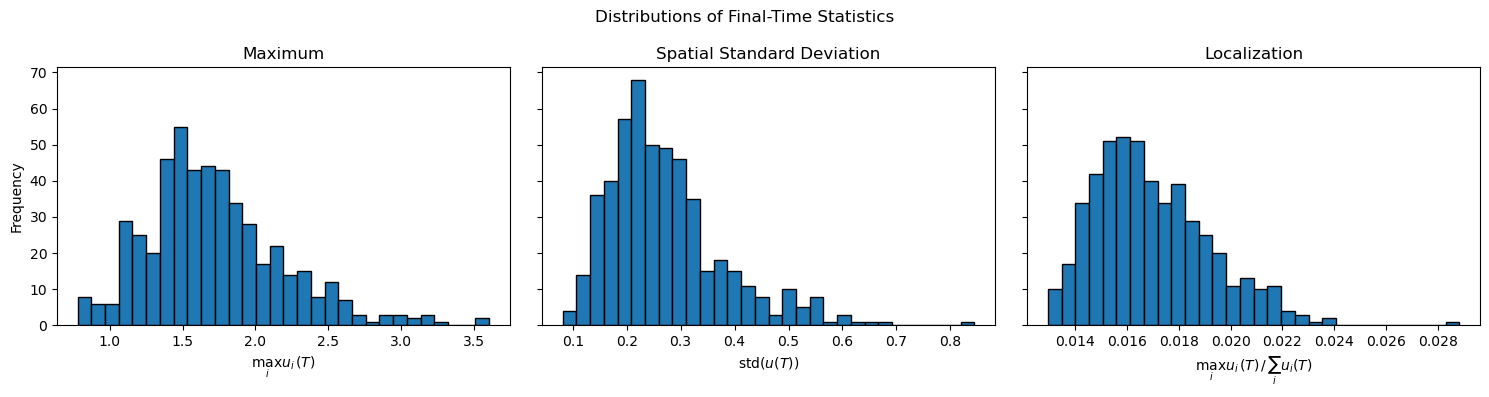

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(final_maxima, bins=30, edgecolor="black")
axes[0].set_title("Maximum")
axes[0].set_xlabel(r"$\max_i u_i(T)$")
axes[0].set_ylabel("Frequency")

axes[1].hist(final_stds, bins=30, edgecolor="black")
axes[1].set_title("Spatial Standard Deviation")
axes[1].set_xlabel(r"$\operatorname{std}(u(T))$")

axes[2].hist(final_localization, bins=30, edgecolor="black")
axes[2].set_title("Localization")
axes[2].set_xlabel(r"$\max_i u_i(T)\,/\,\sum_i u_i(T)$")

fig.suptitle("Distributions of Final-Time Statistics")
plt.tight_layout()
plt.show()

### Influence of the Noise Strength

To investigate the effect of the stochastic forcing, we repeat the Monte Carlo experiment for several values of the noise strength.

For each value of $\sigma$, the random number generator is reset so that the same standardized Gaussian samples are used throughout. This isolates the effect of changing the noise strength from the variability caused by different realizations.

In [9]:
sigmas = [0.5, 1.0, 2.0, 3.0]

In [10]:
sigma_statistics = {
    sigma: {
        "maxima": final_maxima,
        "stds": final_stds,
        "localization": final_localization,
    }
}

for sigma_value in sigmas:
    if sigma_value == sigma:
        continue

    rng = np.random.default_rng(seed)

    maxima = []
    stds = []
    localization = []

    for _ in range(num_simulations):
        result = solve_stochastic_heat_equation(
            u0,
            h,
            dt,
            num_steps,
            kappa=kappa,
            sigma=sigma_value,
            record_every=record_every,
            rng=rng,
        )

        u_final = result["solution"]

        maximum = np.max(u_final)
        mass = np.sum(u_final)

        maxima.append(maximum)
        stds.append(np.std(u_final))
        localization.append(maximum / mass)

    sigma_statistics[sigma_value] = {
        "maxima": np.array(maxima),
        "stds": np.array(stds),
        "localization": np.array(localization),
    }

### Empirical Mean Statistics

Using the Monte Carlo samples, we estimate the mean value of each final-time statistic for every noise strength.

In [11]:
mean_maxima = [
    sigma_statistics[sigma_value]["maxima"].mean()
    for sigma_value in sigmas
]

mean_stds = [
    sigma_statistics[sigma_value]["stds"].mean()
    for sigma_value in sigmas
]

mean_localization = [
    sigma_statistics[sigma_value]["localization"].mean()
    for sigma_value in sigmas
]

### Dependence on the Noise Strength

The following figure compares the empirical means of the maximum value, spatial standard deviation, and localization ratio as functions of the noise strength.

These quantities provide complementary measures of how increasing stochastic forcing influences the spatial behavior of the solution.

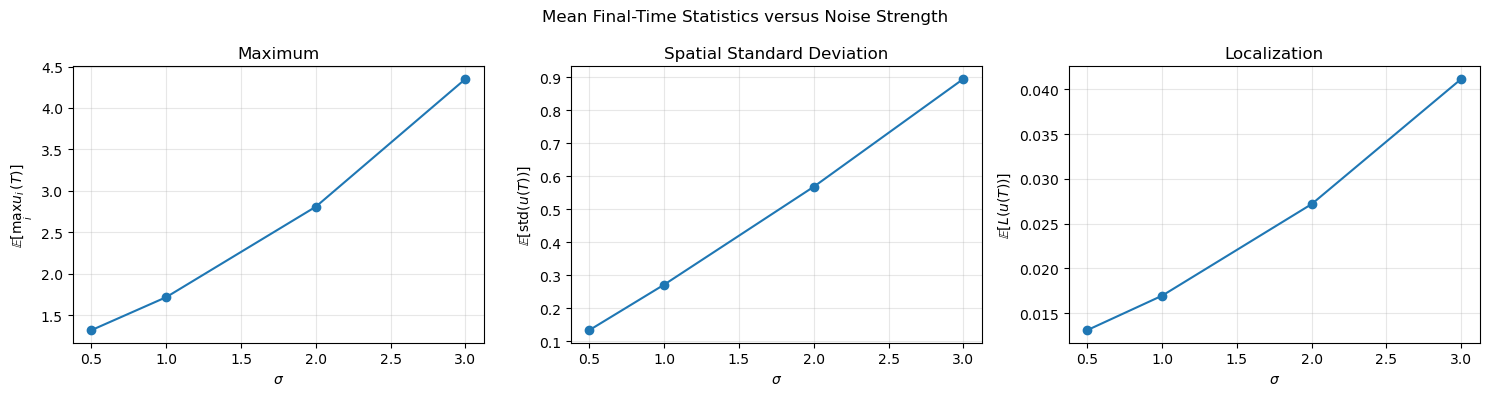

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sigmas, mean_maxima, marker="o")
axes[0].set_title("Maximum")
axes[0].set_xlabel(r"$\sigma$")
axes[0].set_ylabel(r"$\mathbb{E}[\max_i u_i(T)]$")
axes[0].grid(alpha=0.3)

axes[1].plot(sigmas, mean_stds, marker="o")
axes[1].set_title("Spatial Standard Deviation")
axes[1].set_xlabel(r"$\sigma$")
axes[1].set_ylabel(
    r"$\mathbb{E}[\operatorname{std}(u(T))]$"
)
axes[1].grid(alpha=0.3)

axes[2].plot(sigmas, mean_localization, marker="o")
axes[2].set_title("Localization")
axes[2].set_xlabel(r"$\sigma$")
axes[2].set_ylabel(r"$\mathbb{E}[L(u(T))]$")
axes[2].grid(alpha=0.3)

fig.suptitle("Mean Final-Time Statistics versus Noise Strength")
plt.tight_layout()
plt.show()

### Empirical Moments

In addition to final-time summary statistics, Monte Carlo simulation allows us to estimate moments of the solution over time.

For $p\ge1$, we consider the spatially averaged empirical moment

$$
m_p(t)
=
\mathbb{E}
\left[
\frac1N
\sum_{i=1}^{N}
u_i(t)^p
\right].
$$

Here we estimate the first, second, and fourth moments from many independent sample paths.

In [13]:
# Moment estimation parameters
moment_sigma = sigma
num_moment_simulations = 200

In [14]:
rng = np.random.default_rng(seed)

sum_first_moment = None
sum_second_moment = None
sum_fourth_moment = None
moment_times = None

for _ in range(num_moment_simulations):
    result = solve_stochastic_heat_equation(
        u0,
        h,
        dt,
        num_steps,
        kappa=kappa,
        sigma=moment_sigma,
        record_every=record_every,
        rng=rng,
    )

    snapshots = np.asarray(result["snapshots"])

    first_moment_path = np.mean(snapshots, axis=1)
    second_moment_path = np.mean(snapshots**2, axis=1)
    fourth_moment_path = np.mean(snapshots**4, axis=1)

    if sum_first_moment is None:
        moment_times = np.asarray(result["times"])
        sum_first_moment = np.zeros_like(first_moment_path)
        sum_second_moment = np.zeros_like(second_moment_path)
        sum_fourth_moment = np.zeros_like(fourth_moment_path)

    sum_first_moment += first_moment_path
    sum_second_moment += second_moment_path
    sum_fourth_moment += fourth_moment_path

empirical_first_moment = sum_first_moment / num_moment_simulations

empirical_second_moment = sum_second_moment / num_moment_simulations

empirical_fourth_moment = sum_fourth_moment / num_moment_simulations

### Evolution of the Empirical Moments

The following figure compares the first, second, and fourth empirical moments over the simulated time interval.

Higher-order moments place greater weight on large solution values and therefore become increasingly sensitive to the rare peaks generated by the multiplicative noise.

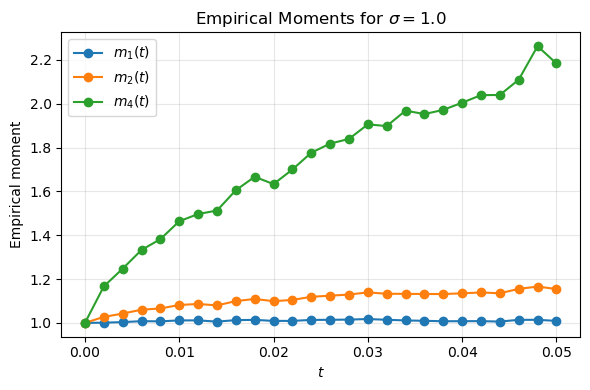

In [15]:
plt.figure(figsize=(6, 4))

plt.plot(
    moment_times,
    empirical_first_moment,
    marker="o",
    label=r"$m_1(t)$",
)

plt.plot(
    moment_times,
    empirical_second_moment,
    marker="o",
    label=r"$m_2(t)$",
)

plt.plot(
    moment_times,
    empirical_fourth_moment,
    marker="o",
    label=r"$m_4(t)$",
)

plt.xlabel(r"$t$")
plt.ylabel("Empirical moment")
plt.title(
    rf"Empirical Moments for $\sigma={moment_sigma}$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Summary

In this notebook, we introduced the Monte Carlo method for the stochastic heat equation and used it to estimate statistical properties of the numerical solution from many independent sample paths.

We examined the empirical distributions of the final maximum value, spatial standard deviation, and localization ratio, investigated how their mean values depend on the noise strength, and estimated the first, second, and fourth empirical moments over time.

In the next notebook, we will replace space-time white noise by spatially correlated noise and investigate how the correlation structure influences the behavior of the solution.